# Temporal abuse-category graphs

## Goal

Compare the same eight aggregate abuse categories across six monthly snapshots with a fixed topology and layout. This preserves visual comparability while keeping the temporal interpretation separate from the static semantic model.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or notebooks directory.")

source_path = str(PROJECT_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display

from disque100_research import ArtifactPaths, ExperimentConfig
from disque100_research.artifacts import (
    assert_public_artifact_safe,
    require_artifact,
    require_matching_manifest,
    write_manifest,
)
from disque100_research.database import query_frame
from disque100_research.visualization import (
    ENTITY_COLORS,
    assert_positive_edge_weights,
    scale_values,
    wrapped_labels,
)

CONFIG = ExperimentConfig.load(PROJECT_ROOT / "experiments" / "female_abuse_2026_h1.toml")
PATHS = ArtifactPaths.for_experiment(PROJECT_ROOT, CONFIG)
PATHS.ensure_directories()
manifest = require_matching_manifest(PATHS, CONFIG)

CATEGORY_SUPPORT_FILE = require_artifact(
    PATHS.results_semantic / "category-support.csv", "02_semantic_abuse_graphs.ipynb"
)
assert_public_artifact_safe(CATEGORY_SUPPORT_FILE)
category_support = pd.read_csv(CATEGORY_SUPPORT_FILE)
top_categories = category_support.head(12)["category"].tolist()
category_count_lookup = category_support.set_index("category")["report_count"].astype(int).to_dict()
female_report_count = int(manifest["observed"]["female_report_count"])
RESULTS_DIR = PATHS.results_temporal

print(f"Loaded {len(top_categories)} aggregate categories with a matching fingerprint.")


Loaded 12 aggregate categories with a matching fingerprint.


## Context and assumptions

This notebook consumes only the privacy-safe category support produced by notebook 02. Monthly nodes and edges are recomputed from PostgreSQL with distinct-report grain.

## 1. Build monthly co-occurrence snapshots

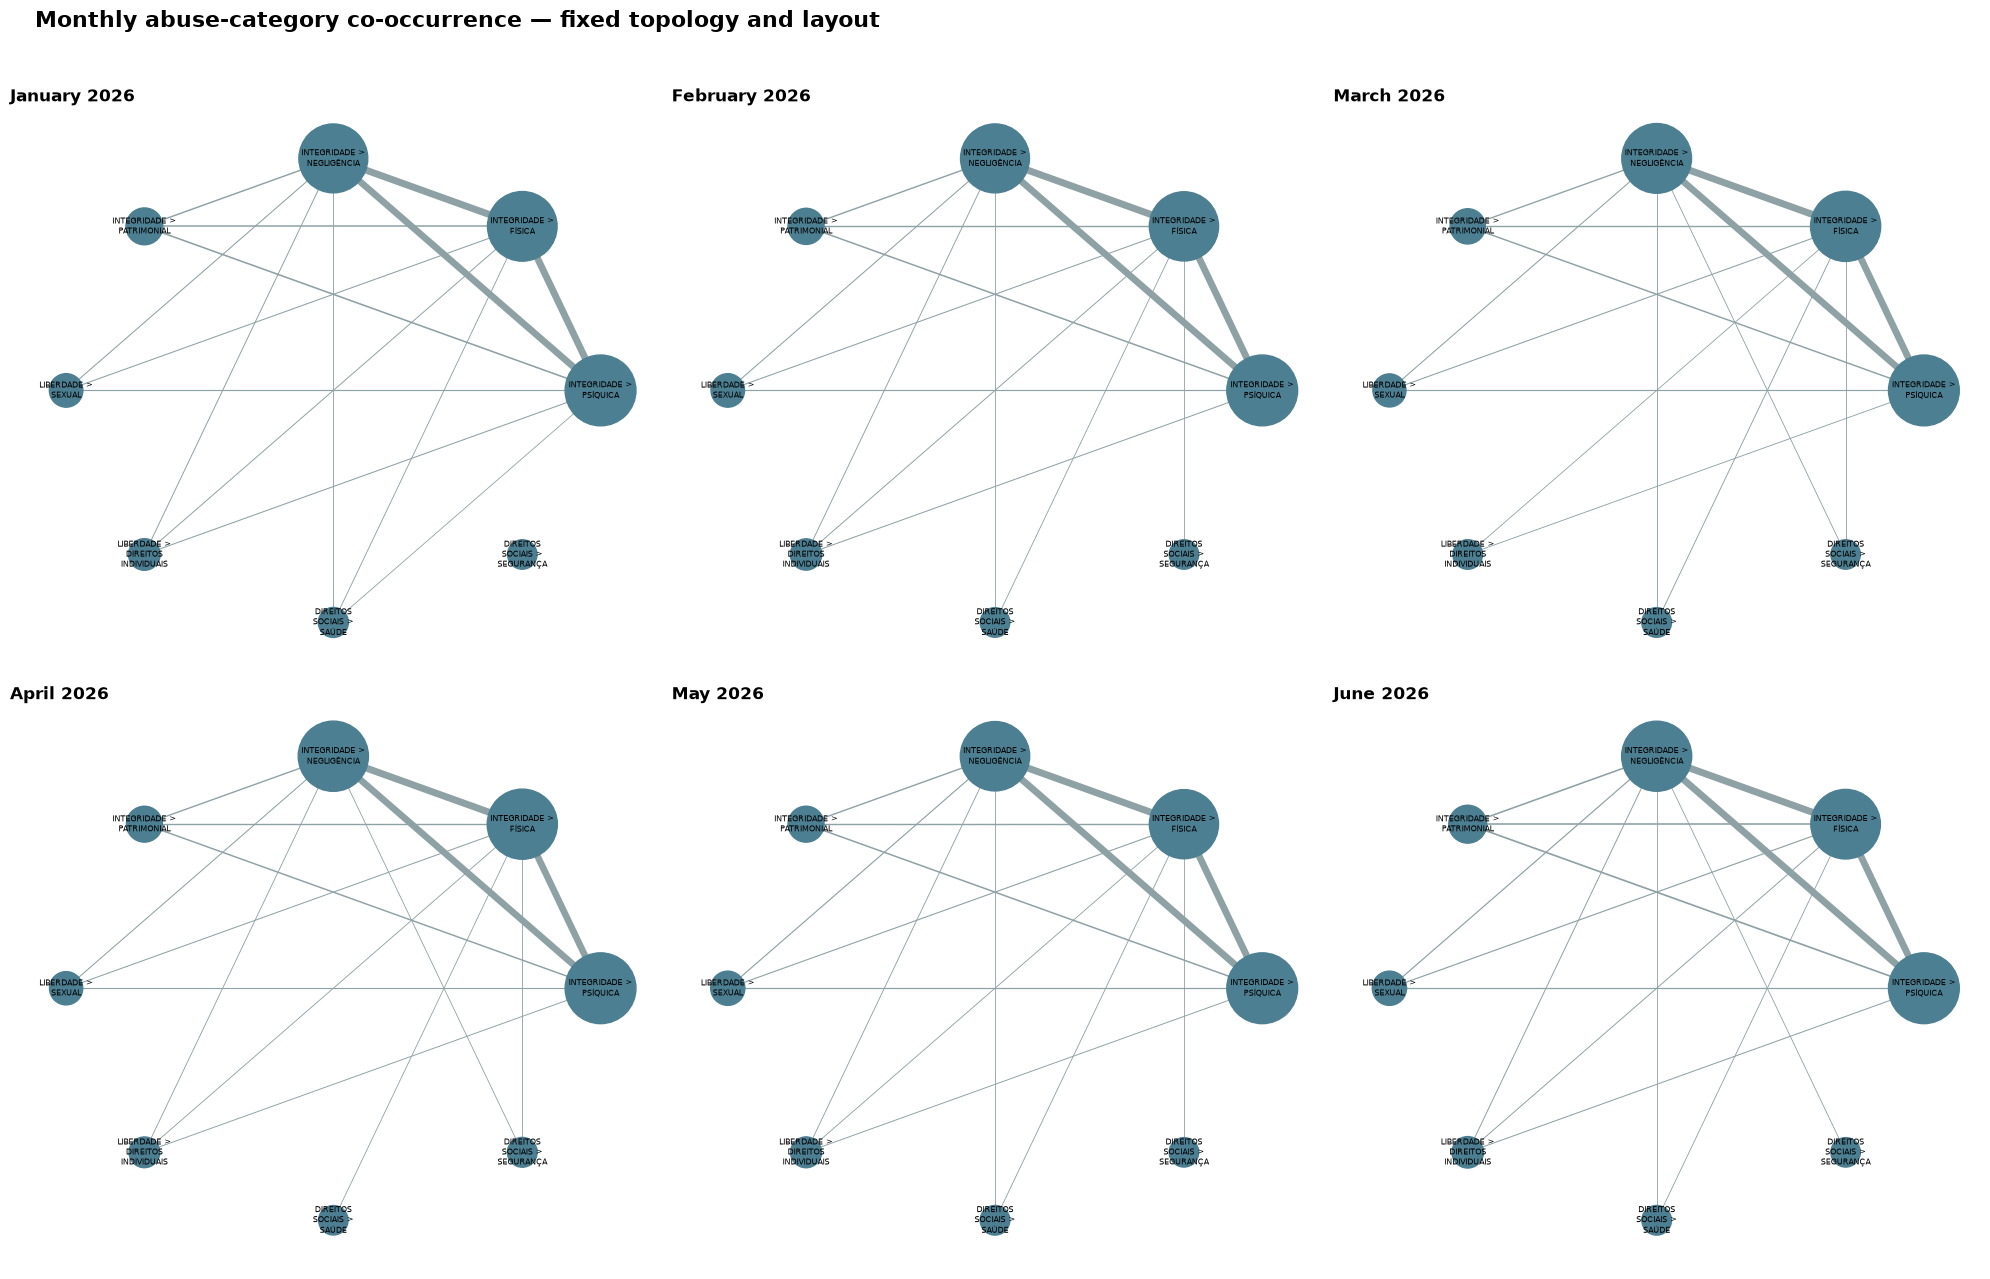

In [2]:
temporal_categories = top_categories[:8]
monthly_node_support = query_frame(CONFIG, 
    """
    SELECT
        date_trunc('month', registered_at)::date AS month,
        concat_ws(
            ' > ',
            nullif(trim(split_part(violation, '>', 1)), ''),
            nullif(trim(split_part(violation, '>', 2)), '')
        ) AS category,
        count(DISTINCT source_hash) AS report_count
    FROM public.disque100_reports
    WHERE registered_at >= %s
      AND registered_at < %s
      AND victim_gender = %s
      AND violation IS NOT NULL
    GROUP BY month, category
    HAVING concat_ws(
        ' > ',
        nullif(trim(split_part(violation, '>', 1)), ''),
        nullif(trim(split_part(violation, '>', 2)), '')
    ) = ANY(%s)
    ORDER BY month, report_count DESC
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender, temporal_categories),
)
monthly_edges = query_frame(CONFIG, 
    """
    WITH report_categories AS (
        SELECT DISTINCT
            source_hash,
            date_trunc('month', registered_at)::date AS month,
            concat_ws(
                ' > ',
                nullif(trim(split_part(violation, '>', 1)), ''),
                nullif(trim(split_part(violation, '>', 2)), '')
            ) AS category
        FROM public.disque100_reports
        WHERE registered_at >= %s
          AND registered_at < %s
          AND victim_gender = %s
          AND violation IS NOT NULL
    ), pairs AS (
        SELECT
            a.month,
            a.category AS source,
            b.category AS target,
            count(*) AS report_count,
            row_number() OVER (
                PARTITION BY a.month ORDER BY count(*) DESC, a.category, b.category
            ) AS edge_rank
        FROM report_categories AS a
        JOIN report_categories AS b
          ON a.source_hash = b.source_hash
         AND a.month = b.month
         AND a.category < b.category
        WHERE a.category = ANY(%s) AND b.category = ANY(%s)
        GROUP BY a.month, a.category, b.category
    )
    SELECT month, source, target, report_count
    FROM pairs
    WHERE edge_rank <= 15
    ORDER BY month, report_count DESC, source, target
    """,
    (CONFIG.registered_from, CONFIG.registered_before, CONFIG.victim_gender, temporal_categories, temporal_categories),
)

months = sorted(monthly_node_support["month"].astype(str).unique())
assert len(months) == 6

overall_temporal_graph = nx.Graph()
for category in temporal_categories:
    overall_temporal_graph.add_node(category)
for row in monthly_edges.itertuples():
    current_weight = overall_temporal_graph.get_edge_data(row.source, row.target, {}).get("weight", 0)
    overall_temporal_graph.add_edge(row.source, row.target, weight=current_weight + int(row.report_count))
fixed_positions = nx.circular_layout(overall_temporal_graph)

temporal_graphs = {}
figure, axes = plt.subplots(2, 3, figsize=(20, 13))
for axis, month in zip(axes.flat, months):
    graph = nx.Graph()
    month_nodes = monthly_node_support[monthly_node_support["month"].astype(str) == month]
    month_node_counts = month_nodes.set_index("category")["report_count"].astype(int).to_dict()
    for category in temporal_categories:
        graph.add_node(
            category,
            node_type="category",
            report_count=month_node_counts.get(category, 0),
        )
    month_edges = monthly_edges[monthly_edges["month"].astype(str) == month]
    for row in month_edges.itertuples():
        graph.add_edge(
            row.source,
            row.target,
            relation="co-occurs with",
            month=month,
            weight=int(row.report_count),
        )
    assert_positive_edge_weights(graph)
    temporal_graphs[month] = graph

    node_counts = [graph.nodes[node]["report_count"] for node in graph.nodes]
    edge_counts = [data["weight"] for _, _, data in graph.edges(data=True)]
    nx.draw_networkx(
        graph,
        pos=fixed_positions,
        ax=axis,
        labels=wrapped_labels(graph, 14),
        node_color=ENTITY_COLORS["category"],
        node_size=scale_values(node_counts, 450, 2600),
        edge_color="#8EA1A5",
        width=scale_values(edge_counts, 0.6, 5),
        font_size=6,
    )
    axis.set_title(pd.Timestamp(month).strftime("%B %Y"), loc="left", weight="bold")
    axis.axis("off")

figure.suptitle(
    "Monthly abuse-category co-occurrence — fixed topology and layout",
    x=0.02, ha="left", fontsize=16, weight="bold",
)
figure.patch.set_facecolor("white")
figure.tight_layout(rect=[0, 0, 1, 0.96])
temporal_png = RESULTS_DIR / "abuse-temporal.png"
figure.savefig(temporal_png, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

temporal_export = nx.MultiGraph()
for category in temporal_categories:
    temporal_export.add_node(
        category,
        node_type="category",
        report_count=category_count_lookup[category],
    )
for month, graph in temporal_graphs.items():
    for edge_index, (source, target, data) in enumerate(graph.edges(data=True)):
        temporal_export.add_edge(
            source,
            target,
            key=f"{month}-{edge_index}",
            relation="co-occurs with",
            month=month,
            weight=int(data["weight"]),
        )
nx.write_graphml(temporal_export, RESULTS_DIR / "temporal-cooccurrence.graphml")

## 2. Interpretation and caveats

### What the analysis adds

- **Semantic graphs:** source concepts become labeled nodes, and distinct-report co-occurrence becomes a weighted relation.
- **Knowledge graphs:** the anonymized example makes entity types and named relations explicit without exposing a report identifier.
- **Data enrichment:** the original `violation` string is decomposed into domain, category, subtype, and detail while preserving the source taxonomy.
- **Temporal graph visualization:** the same category network is compared across six monthly snapshots with a fixed layout.

### What the analysis does not prove

- DAMICORE cluster IDs are structural group identifiers, not abuse types.
- Cluster profiles describe frequent attributes; they are not validated social typologies.
- Co-occurrence is an association inside reported records, not causation.
- Report counts measure Disque 100 records in this period. They do not estimate population prevalence, unreported abuse, or individual risk.
- Repeated source categories can reflect the denormalized reporting design, so every reported count uses distinct `source_hash`.

## 3. Validate and summarize the temporal experiment

In [3]:
temporal_png = require_artifact(
    RESULTS_DIR / "abuse-temporal.png", "03_temporal_abuse_graphs.ipynb"
)
temporal_graphml = require_artifact(
    RESULTS_DIR / "temporal-cooccurrence.graphml", "03_temporal_abuse_graphs.ipynb"
)
assert_public_artifact_safe(temporal_graphml)
assert_positive_edge_weights(temporal_export)
assert len(months) == 6

write_manifest(
    PATHS,
    CONFIG,
    {
        "temporal_months": len(months),
        "temporal_png_files": 1,
        "temporal_graphml_files": 1,
    },
)

display(monthly_node_support.head(16))
print("Temporal analysis checks passed.")
print(f"Female-victim reports: {female_report_count:,}")
print(f"Monthly snapshots: {len(months)}")
print("Interpret edges as reported co-occurrence, never as causal relations.")


,month,category,report_count
0,2026-01-01,INTEGRIDADE > PSÍQUICA,24746
1,2026-01-01,INTEGRIDADE > FÍSICA,23785
2,2026-01-01,INTEGRIDADE > NEGLIGÊNCIA,23193
3,2026-01-01,INTEGRIDADE > PATRIMONIAL,3818
4,2026-01-01,LIBERDADE > SEXUAL,2481
5,2026-01-01,LIBERDADE > DIREITOS INDIVIDUAIS,1784
6,2026-01-01,DIREITOS SOCIAIS > SAÚDE,1221
7,2026-01-01,DIREITOS SOCIAIS > SEGURANÇA,1018
8,2026-02-01,INTEGRIDADE > PSÍQUICA,24349
9,2026-02-01,INTEGRIDADE > FÍSICA,23102


Temporal analysis checks passed.
Female-victim reports: 189,909
Monthly snapshots: 6
Interpret edges as reported co-occurrence, never as causal relations.


## Takeaways

The temporal panels show how the strength of reported category associations changes month by month. They do not establish temporal causality, population prevalence, unreported abuse, or individual risk.